# Phase 3: Baseline Modelling
## Project: Kataoka Inc. Predictive Maintenance System

---

## Business Context

The goal of this phase is to establish a performance benchmark for
Remaining Useful Life (RUL) prediction before any feature engineering
or hyperparameter tuning is applied.

A baseline model answers one critical question:
**How well can we predict RUL using raw sensor values alone?**

This benchmark is essential because:
- It gives us a reference point to measure improvement against
- It tells us whether the raw signal carries any predictive value at all
- It prevents us from over-engineering features that may not help

---

## What This Phase Covers

- Load the processed RUL dataset (17 failure robots, 15,245 readings)
- Perform robot-level train/test split to prevent data leakage
- Encode categorical features
- Apply sample weighting to address class imbalance
- Train three baseline models on raw sensor features only:
  Random Forest, Gradient Boosting, Support Vector Regression
- Evaluate with MAE, RMSE, R² overall and segmented by risk zone
- Log all runs in MLflow with stage=baseline tag

---

## Critical Rules

- Split is by robot_id, never by row
- No engineered features in this phase, raw sensor values only
- No hyperparameter tuning, default parameters only
- Sample weighting applied to give Critical zone readings more influence
- Evaluation reported per risk zone, not just overall
- MLflow logging is mandatory for every run

---

## Section 1: Imports and Data Loading

In [35]:
# Imports libraries and sets up environment for RUL predictive maintenance analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load RUL dataset 
# This dataset contains only the 17 confirmed failure robots.
# All 15,245 rows have valid RUL labels grounded in confirmed failure times.

rul_df = pd.read_csv(
    "../data/processed/rul_dataset.csv",
    parse_dates=["timestamp", "failure_time"]
)

print("RUL dataset loaded.")
print(f"  Shape   : {rul_df.shape}")
print(f"  Robots  : {rul_df['robot_id'].nunique()}")
print(f"  Columns : {rul_df.columns.tolist()}")

RUL dataset loaded.
  Shape   : (15245, 25)
  Robots  : 17
  Columns : ['reading_id', 'robot_id', 'timestamp', 'vibration_level', 'motor_temperature', 'torque_load', 'power_consumption', 'model_type', 'factory_location', 'operating_environment', 'cumulative_hours', 'failure_time', 'rul_hours_raw', 'rul_hours', 'is_failure_robot', 'label_status', 'total_maintenance_count', 'total_downtime_hours', 'avg_downtime_hours', 'repair_count', 'replacement_count', 'lubrication_count', 'calibration_count', 'inspection_count', 'health_risk_label']


## Section 2: Feature Selection for Baseline Model

For the baseline model we use raw sensor values only.
No engineered features, no rolling statistics, no trend calculations.

This is intentional. The baseline must reflect model performance
without any feature engineering so we have a honest benchmark
to compare against in Phase 5.

Raw features used:
- vibration_level
- motor_temperature
- torque_load
- power_consumption
- cumulative_hours
- model_type (encoded)
- factory_location (encoded)
- operating_environment (encoded)
- maintenance aggregate features

Target variable: rul_hours

In [36]:
# Define feature columns for baseline model.
# Raw sensor readings, cumulative hours, robot context, maintenance aggregates.
# No rolling windows, no trend features, no engineered signals.

RAW_FEATURES = [
    # Raw sensor readings
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption",

    # Operational context
    "cumulative_hours",

    # Maintenance aggregates (from Phase 2)
    "total_maintenance_count",
    "total_downtime_hours",
    "avg_downtime_hours",
    "repair_count",
    "replacement_count",
    "lubrication_count",
    "calibration_count",
    "inspection_count",

    # Categorical context (will be encoded below)
    "model_type",
    "factory_location",
    "operating_environment",
]

TARGET = "rul_hours"

print(f"Features selected : {len(RAW_FEATURES)}")
print(f"Target variable   : {TARGET}")
print(f"\nFeature list:")
for f in RAW_FEATURES:
    print(f"  {f}")

Features selected : 16
Target variable   : rul_hours

Feature list:
  vibration_level
  motor_temperature
  torque_load
  power_consumption
  cumulative_hours
  total_maintenance_count
  total_downtime_hours
  avg_downtime_hours
  repair_count
  replacement_count
  lubrication_count
  calibration_count
  inspection_count
  model_type
  factory_location
  operating_environment


## Section 3: Encode Categorical Features

Three categorical columns need to be converted to numbers
before the model can process them:
- model_type (5 categories)
- factory_location (5 categories)
- operating_environment (4 categories)

We use Label Encoding here for the baseline model.
This is simple and appropriate for tree-based models
which do not assume any ordinal relationship between categories.

In [37]:
# Encode categorical features
# We create a working copy to avoid modifying the original dataframe.
# Label encoding converts each unique category to an integer.
# Tree-based models (Random Forest, Gradient Boosting) handle this well.

model_df = rul_df.copy()

categorical_cols = ["model_type", "factory_location", "operating_environment"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col + "_encoded"] = le.fit_transform(model_df[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Define two explicit baseline feature sets for ablation testing.

# Baseline A: raw sensor readings only
# Tests whether sensors alone carry predictive signal
BASELINE_A_FEATURES = [
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption",
]

# Baseline B: sensors + operational context + maintenance aggregates
# Tests whether adding robot context and history improves predictions
BASELINE_B_FEATURES = [
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption",
    "cumulative_hours",
    "total_maintenance_count",
    "total_downtime_hours",
    "avg_downtime_hours",
    "repair_count",
    "replacement_count",
    "lubrication_count",
    "calibration_count",
    "inspection_count",
    "model_type_encoded",
    "factory_location_encoded",
    "operating_environment_encoded",
]

print(f"\nBaseline A: {len(BASELINE_A_FEATURES)} features (raw sensors only)")
print(f"Baseline B: {len(BASELINE_B_FEATURES)} features (sensors + context + maintenance)")

print(f"\nBaseline A features:")
for f in BASELINE_A_FEATURES:
    print(f"  {f}")

print(f"\nBaseline B features:")
for f in BASELINE_B_FEATURES:
    print(f"  {f}")

model_type: {'ARM-X7': np.int64(0), 'ARM-X9': np.int64(1), 'ASSEMBLY-A3': np.int64(2), 'CONVEYOR-C2': np.int64(3)}
factory_location: {'Fukuoka Center': np.int64(0), 'Hokkaido Lab': np.int64(1), 'Nagoya Site': np.int64(2), 'Osaka Plant': np.int64(3), 'Tokyo Factory': np.int64(4)}
operating_environment: {'Clean Room (20-22°C, 40% RH)': np.int64(0), 'Climate Controlled (22-25°C, 50% RH)': np.int64(1), 'Heavy Industrial (30-40°C, 70% RH)': np.int64(2), 'Standard Factory (25-30°C, 60% RH)': np.int64(3)}

Baseline A: 4 features (raw sensors only)
Baseline B: 16 features (sensors + context + maintenance)

Baseline A features:
  vibration_level
  motor_temperature
  torque_load
  power_consumption

Baseline B features:
  vibration_level
  motor_temperature
  torque_load
  power_consumption
  cumulative_hours
  total_maintenance_count
  total_downtime_hours
  avg_downtime_hours
  repair_count
  replacement_count
  lubrication_count
  calibration_count
  inspection_count
  model_type_encoded
  f

## Section 4: Robot-Level Train/Test Split

We split by robot_id, not by row.

Splitting by row would allow the model to see readings from
the same robot in both training and test sets. Because sensor
readings from the same robot are temporally correlated, this
would constitute data leakage. The model would learn robot-specific
patterns rather than generalising across the fleet.

Splitting by robot ensures the test set contains robots the model
has never seen during training. This is the honest evaluation
that reflects real deployment conditions.

Split strategy:
- 13 robots for training
- 4 robots for testing
- Reviewed for data volume balance across robot types

In [38]:
# Robot-level train/test split 
# We split by robot_id, not by row, to prevent data leakage.
# The test set is constructed deliberately to ensure model type coverage.
# With 17 robots across 4 model types, a random or mechanical split
# risks leaving some model types entirely absent from evaluation.
# We select one robot per model type for the test set where possible,
# choosing the robot with the most readings to ensure enough test data.

# Sort robots by reading count within each model type
robot_sizes = (
    model_df.groupby(["robot_id", "model_type"])["rul_hours"]
    .count()
    .reset_index()
)
robot_sizes.columns = ["robot_id", "model_type", "reading_count"]
robot_sizes = robot_sizes.sort_values(
    ["model_type", "reading_count"], ascending=[True, False]
)

print("Robot Reading Counts by Model Type")
display(robot_sizes)

# Select one test robot per model type 
# Pick the robot with the most readings per model type for testing.
# More readings = more reliable test evaluation.

test_robots = (
    robot_sizes.groupby("model_type")
    .apply(lambda x: x.nlargest(1, "reading_count"))
    .reset_index(drop=True)
)["robot_id"].tolist()

train_robots = [
    r for r in robot_sizes["robot_id"].tolist()
    if r not in test_robots
]

print(f"\nTest robots  ({len(test_robots)}) : {test_robots}")
print(f"Train robots ({len(train_robots)}): {train_robots}")

# Validate no overlap
assert len(set(train_robots) & set(test_robots)) == 0, \
    "Overlap detected between train and test robots."
print("\nNo overlap confirmed. Split is clean.")

# Create train and test sets
train_df = model_df[model_df["robot_id"].isin(train_robots)].copy()
test_df  = model_df[model_df["robot_id"].isin(test_robots)].copy()

print(f"\nTrain set : {train_df.shape[0]} rows, {train_df['robot_id'].nunique()} robots")
print(f"Test set  : {test_df.shape[0]} rows,  {test_df['robot_id'].nunique()} robots")

print(f"\nModel type coverage:")
print(f"  Train : {sorted(train_df['model_type'].unique())}")
print(f"  Test  : {sorted(test_df['model_type'].unique())}")

print(f"\nRisk zone distribution in train set:")
print(train_df["health_risk_label"].value_counts())

print(f"\nRisk zone distribution in test set:")
print(test_df["health_risk_label"].value_counts())

Robot Reading Counts by Model Type


,robot_id,model_type,reading_count
5,ROB-0018,ARM-X7,1225
8,ROB-0028,ARM-X7,1225
10,ROB-0032,ARM-X7,1185
0,ROB-0007,ARM-X7,1137
16,ROB-0049,ARM-X7,901
1,ROB-0009,ARM-X7,645
3,ROB-0014,ARM-X7,581
6,ROB-0023,ARM-X9,1357
12,ROB-0037,ARM-X9,929
13,ROB-0042,ARM-X9,845



Test robots  (4) : ['ROB-0018', 'ROB-0023', 'ROB-0013', 'ROB-0027']
Train robots (13): ['ROB-0028', 'ROB-0032', 'ROB-0007', 'ROB-0049', 'ROB-0009', 'ROB-0014', 'ROB-0037', 'ROB-0042', 'ROB-0044', 'ROB-0035', 'ROB-0031', 'ROB-0043', 'ROB-0016']

No overlap confirmed. Split is clean.

Train set : 10129 rows, 13 robots
Test set  : 5116 rows,  4 robots

Model type coverage:
  Train : ['ARM-X7', 'ARM-X9', 'ASSEMBLY-A3', 'CONVEYOR-C2']
  Test  : ['ARM-X7', 'ARM-X9', 'ASSEMBLY-A3', 'CONVEYOR-C2']

Risk zone distribution in train set:
health_risk_label
Healthy     8569
Warning     1196
Critical     364
Name: count, dtype: int64

Risk zone distribution in test set:
health_risk_label
Healthy     4636
Warning      368
Critical     112
Name: count, dtype: int64


=== RUL Distribution: Train vs Test ===

Train RUL:
count   10129.00
mean     2618.30
std      1777.70
min         0.00
25%      1164.00
50%      2334.00
75%      3810.00
max      7344.00
Name: rul_hours, dtype: float64

Test RUL:
count   5116.00
mean    3848.10
std     2239.70
min        0.00
25%     1914.00
50%     3834.00
75%     5754.00
max     8136.00
Name: rul_hours, dtype: float64


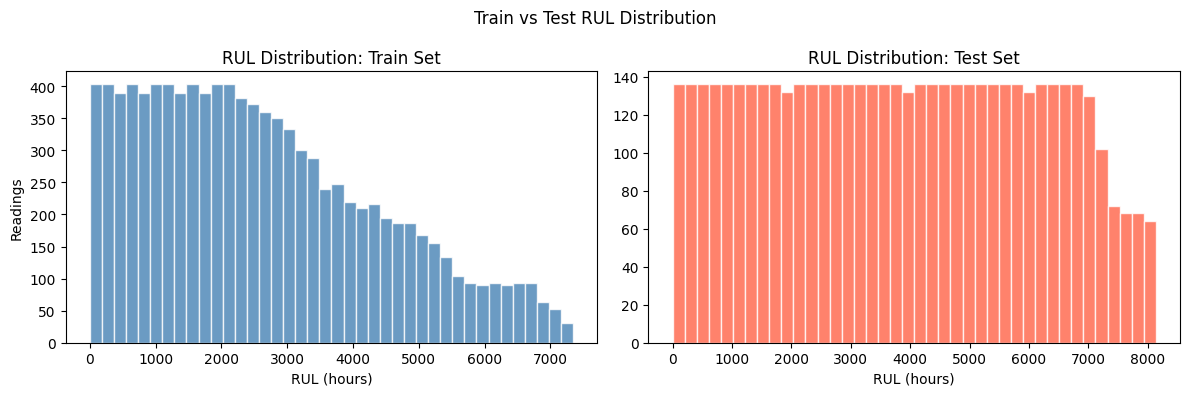

In [39]:
# RUL distribution check across train and test sets
# We confirm that both sets contain readings across the full RUL range.
# A test set with only high RUL readings would produce artificially
# easy evaluation metrics.

print("=== RUL Distribution: Train vs Test ===")
print(f"\nTrain RUL:")
print(train_df["rul_hours"].describe().round(1))
print(f"\nTest RUL:")
print(test_df["rul_hours"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df["rul_hours"], bins=40, color="steelblue",
             edgecolor="white", alpha=0.8)
axes[0].set_title("RUL Distribution: Train Set")
axes[0].set_xlabel("RUL (hours)")
axes[0].set_ylabel("Readings")

axes[1].hist(test_df["rul_hours"], bins=40, color="tomato",
             edgecolor="white", alpha=0.8)
axes[1].set_title("RUL Distribution: Test Set")
axes[1].set_xlabel("RUL (hours)")

plt.suptitle("Train vs Test RUL Distribution", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/train_test_rul_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Section 5: Sample Weights

The training set has a severe class imbalance:
- Healthy  : 8,569 readings (84.6%)
- Warning  : 1,196 readings (11.8%)
- Critical :   364 readings (3.6%)

Without correction, the model will optimise primarily for Healthy
readings because they dominate the training signal.

We apply inverse-frequency sample weights to give Critical and Warning
readings proportionally more influence during training.

Critical readings receive the highest weight because they represent
the most business-critical period. Missing a Critical prediction
means Kataoka engineers receive no warning before failure occurs.

In [40]:
# Compute sample weights for training set
# Inverse frequency weighting gives more weight to underrepresented zones.
# Weight = total_samples / (n_classes * class_count)
# This ensures the model does not simply learn to predict Healthy always.

zone_counts = train_df["health_risk_label"].value_counts()
total_train  = len(train_df)
n_classes    = len(zone_counts)

zone_weights = {
    zone: total_train / (n_classes * count)
    for zone, count in zone_counts.items()
}

print("Zone Weights (inverse frequency)")
for zone, weight in zone_weights.items():
    print(f"  {zone:<12} : count={zone_counts[zone]:>5},  weight={weight:.4f}")

# Assign weight to each training row based on its health risk label
train_df["sample_weight"] = train_df["health_risk_label"].map(zone_weights)

print(f"\nSample weight assigned to all {len(train_df)} training rows.")
print(f"\nWeight distribution:")
print(train_df["sample_weight"].value_counts().sort_index())

Zone Weights (inverse frequency)
  Healthy      : count= 8569,  weight=0.3940
  Critical     : count=  364,  weight=9.2756

Sample weight assigned to all 10129 training rows.

Weight distribution:
sample_weight
0.39    8569
2.82    1196
9.28     364
Name: count, dtype: int64


## Section 6: Prepare Feature Matrices

We extract the feature matrix X and target vector y
for both train and test sets.

SVR requires feature scaling because it is sensitive to
the magnitude of input values. Random Forest and Gradient
Boosting are scale-invariant but we scale all features
consistently for fair comparison.

The scaler is fitted on training data only. Fitting on
the full dataset would constitute data leakage because
the scaler would incorporate information from test robots.

In [41]:
# Extract feature matrices for both baselines

# Baseline A: sensors only
X_train_A = train_df[BASELINE_A_FEATURES].values
X_test_A  = test_df[BASELINE_A_FEATURES].values

# Baseline B: full context
X_train_B = train_df[BASELINE_B_FEATURES].values
X_test_B  = test_df[BASELINE_B_FEATURES].values

# Target and weights are the same for both
y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values
w_train = train_df["sample_weight"].values

# Scale features using training set statistics only 
scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled  = scaler_A.transform(X_test_A)

scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled  = scaler_B.transform(X_test_B)

print(f"Baseline A: X_train={X_train_A_scaled.shape}, X_test={X_test_A_scaled.shape}")
print(f"Baseline B: X_train={X_train_B_scaled.shape}, X_test={X_test_B_scaled.shape}")
print(f"y_train={y_train.shape}, y_test={y_test.shape}")
print(f"\nScalers fitted on training data only.")

Baseline A: X_train=(10129, 4), X_test=(5116, 4)
Baseline B: X_train=(10129, 16), X_test=(5116, 16)
y_train=(10129,), y_test=(5116,)

Scalers fitted on training data only.


## Section 8: Evaluation Helper Function

We define a reusable evaluation function that computes metrics
both overall and segmented by risk zone.

Zone-segmented evaluation is critical for this project because
overall MAE is not a sufficient measure of business value.
A model that performs well overall but misses Critical zone
predictions delivers no protection against unplanned downtime.

In [42]:
# Evaluation helper function 

def evaluate_rul_model(y_true, y_pred, test_df, model_name):
    """
    Evaluates a RUL regression model overall and per risk zone.

    Computes MAE, RMSE, and R² for the full test set and separately
    for Critical, Warning, and Healthy zones.

    Critical zone performance is the primary business metric because
    it reflects how well the model detects imminent failures.

    Parameters:
    -----------
    y_true     : array of true RUL values
    y_pred     : array of predicted RUL values
    test_df    : DataFrame containing health_risk_label column
    model_name : string label for display

    Returns:
    --------
    dict : all computed metrics
    """

    # Overall metrics 
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Overall MAE  : {mae:.1f} hours  ({mae/24:.1f} days)")
    print(f"  Overall RMSE : {rmse:.1f} hours  ({rmse/24:.1f} days)")
    print(f"  Overall R²   : {r2:.4f}")

    # Per risk zone metrics 
    metrics = {
        "model"       : model_name,
        "overall_mae" : round(mae, 2),
        "overall_rmse": round(rmse, 2),
        "overall_r2"  : round(r2, 4),
    }

    print(f"\n  {'Zone':<12} {'N':>5} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
    print(f"  {'-'*50}")

    for zone in ["Critical", "Warning", "Healthy"]:
        mask = test_df["health_risk_label"].values == zone
        if mask.sum() == 0:
            continue

        z_mae  = mean_absolute_error(y_true[mask], y_pred[mask])
        z_rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
        z_r2   = r2_score(y_true[mask], y_pred[mask]) if mask.sum() > 1 else np.nan

        print(f"  {zone:<12} {mask.sum():>5} {z_mae:>10.1f} {z_rmse:>10.1f} {z_r2:>8.4f}")

        metrics[f"{zone.lower()}_mae"]  = round(z_mae, 2)
        metrics[f"{zone.lower()}_rmse"] = round(z_rmse, 2)
        metrics[f"{zone.lower()}_r2"]   = round(z_r2, 4)

    return metrics

## Section 9: Train Baseline Models

We train three models on both baseline feature sets.

For each model we:
- Train with sample weights to address class imbalance
- Evaluate on the held-out test robots
- Report metrics overall and per risk zone
- Log everything to MLflow

Models trained:
- Random Forest Regressor (default parameters)
- Gradient Boosting Regressor (default parameters)
- Support Vector Regression (default parameters, scaled features)

No hyperparameter tuning at this stage.
Default parameters only.

In [52]:
# MLflow setup with PostgreSQL backend
from dotenv import load_dotenv
import os

# Load PostgreSQL tracking URI from .env file
load_dotenv("../.env")
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment("kataoka_rul_predictive_maintenance")

print(f"MLflow tracking URI : {os.getenv('MLFLOW_TRACKING_URI')}")
print(f"MLflow experiment   : kataoka_rul_predictive_maintenance")

# Model definitions
# Default parameters only. No tuning at this stage.

models = {
    "RandomForest"     : RandomForestRegressor(n_estimators=100,
                                               random_state=42,
                                               n_jobs=-1),
    "GradientBoosting" : GradientBoostingRegressor(n_estimators=100,
                                                   random_state=42),
    "SVR"              : SVR(kernel="rbf"),
}

# Store all results for comparison
all_results = []

print(f"\nModels to train : {list(models.keys())}")
print(f"Baselines       : A (4 features), B (16 features)")
print(f"\nStarting training...")

MLflow tracking URI : ../mlruns
MLflow experiment   : kataoka_rul_predictive_maintenance

Models to train : ['RandomForest', 'GradientBoosting', 'SVR']
Baselines       : A (4 features), B (16 features)

Starting training...


In [44]:
# Training loop: Baseline A (raw sensors only)

print("=" * 60)
print("BASELINE A: Raw Sensors Only (4 features)")
print("=" * 60)

for model_name, model in models.items():

    run_name = f"baseline_A_{model_name}"

    with mlflow.start_run(run_name=run_name):

        # Log parameters to MLflow
        mlflow.log_param("model_type",      model_name)
        mlflow.log_param("baseline",        "A_sensors_only")
        mlflow.log_param("n_features",      len(BASELINE_A_FEATURES))
        mlflow.log_param("features",        BASELINE_A_FEATURES)
        mlflow.log_param("train_robots",    len(train_robots))
        mlflow.log_param("test_robots",     len(test_robots))
        mlflow.log_param("train_rows",      len(X_train_A))
        mlflow.log_param("test_rows",       len(X_test_A))
        mlflow.log_param("sample_weighted", True)
        mlflow.log_param("split_strategy",  "robot_level")

        # Set tags
        mlflow.set_tag("stage",          "baseline")
        mlflow.set_tag("data_version",   "raw_features")
        mlflow.set_tag("split_strategy", "robot_level")
        mlflow.set_tag("baseline_set",   "A_sensors_only")

        # Train model 
        # SVR does not support sample_weight so we train it unweighted.
        # All tree-based models support sample_weight.

        if model_name == "SVR":
            model.fit(X_train_A_scaled, y_train)
        else:
            model.fit(X_train_A_scaled, y_train, sample_weight=w_train)

        # Predict
        y_pred = model.predict(X_test_A_scaled)
        y_pred = np.clip(y_pred, 0, None)  # RUL cannot be negative

        # Evaluate 
        results = evaluate_rul_model(y_test, y_pred, test_df,
                                     f"Baseline A: {model_name}")
        results["baseline"] = "A"
        all_results.append(results)

        # Log metrics to MLflow
        mlflow.log_metric("mae",           results["overall_mae"])
        mlflow.log_metric("rmse",          results["overall_rmse"])
        mlflow.log_metric("r2",            results["overall_r2"])
        mlflow.log_metric("critical_mae",  results.get("critical_mae", -1))
        mlflow.log_metric("warning_mae",   results.get("warning_mae", -1))
        mlflow.log_metric("healthy_mae",   results.get("healthy_mae", -1))

        # Log model artifact 
        mlflow.sklearn.log_model(model, "model")

        print(f"\n  MLflow run logged: {run_name}")

BASELINE A: Raw Sensors Only (4 features)


2026/05/04 02:59:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:59:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Baseline A: RandomForest
  Overall MAE  : 2026.9 hours  (84.5 days)
  Overall RMSE : 2453.7 hours  (102.2 days)
  Overall R²   : -0.2005

  Zone             N        MAE       RMSE       R²
  --------------------------------------------------
  Critical       112     2310.5     2443.3 -2540.2899
  Warning        368     1974.1     2126.3 -177.0826
  Healthy       4636     2024.3     2478.1  -0.4842

  MLflow run logged: baseline_A_RandomForest


2026/05/04 02:59:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:59:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Baseline A: GradientBoosting
  Overall MAE  : 2629.2 hours  (109.6 days)
  Overall RMSE : 3225.0 hours  (134.4 days)
  Overall R²   : -1.0738

  Zone             N        MAE       RMSE       R²
  --------------------------------------------------
  Critical       112     1055.6     1155.6 -567.5341
  Warning        368      749.4      888.4 -30.0864
  Healthy       4636     2816.5     3373.8  -1.7511

  MLflow run logged: baseline_A_GradientBoosting


2026/05/04 02:59:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:59:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Baseline A: SVR
  Overall MAE  : 2215.4 hours  (92.3 days)
  Overall RMSE : 2693.3 hours  (112.2 days)
  Overall R²   : -0.4464

  Zone             N        MAE       RMSE       R²
  --------------------------------------------------
  Critical       112     2208.5     2210.1 -2078.3377
  Warning        368     1858.1     1866.6 -136.2276
  Healthy       4636     2244.0     2758.7  -0.8394

  MLflow run logged: baseline_A_SVR


In [45]:
# Training loop: Baseline B (sensors + context + maintenance)

print("=" * 60)
print("BASELINE B: Sensors + Context + Maintenance (16 features)")
print("=" * 60)

# Re-initialise models with same parameters for fair comparison
models_B = {
    "RandomForest"       : RandomForestRegressor(n_estimators=100,
                                                  random_state=42,
                                                  n_jobs=-1),
    "GradientBoosting"   : GradientBoostingRegressor(n_estimators=100,
                                                      random_state=42),
    "SVR"                : SVR(kernel="rbf"),
}

for model_name, model in models_B.items():

    run_name = f"baseline_B_{model_name}"

    with mlflow.start_run(run_name=run_name):

        # Log parameters 
        mlflow.log_param("model_type",      model_name)
        mlflow.log_param("baseline",        "B_full_context")
        mlflow.log_param("n_features",      len(BASELINE_B_FEATURES))
        mlflow.log_param("features",        BASELINE_B_FEATURES)
        mlflow.log_param("train_robots",    len(train_robots))
        mlflow.log_param("test_robots",     len(test_robots))
        mlflow.log_param("train_rows",      len(X_train_B))
        mlflow.log_param("test_rows",       len(X_test_B))
        mlflow.log_param("sample_weighted", True)
        mlflow.log_param("split_strategy",  "robot_level")

        # Set tags 
        mlflow.set_tag("stage",          "baseline")
        mlflow.set_tag("data_version",   "raw_features")
        mlflow.set_tag("split_strategy", "robot_level")
        mlflow.set_tag("baseline_set",   "B_full_context")

        # Train model 
        if model_name == "SVR":
            model.fit(X_train_B_scaled, y_train)
        else:
            model.fit(X_train_B_scaled, y_train, sample_weight=w_train)

        # Predict
        y_pred = model.predict(X_test_B_scaled)
        y_pred = np.clip(y_pred, 0, None)

        # Evaluate 
        results = evaluate_rul_model(y_test, y_pred, test_df,
                                     f"Baseline B: {model_name}")
        results["baseline"] = "B"
        all_results.append(results)

        # Log metrics to MLflow
        mlflow.log_metric("mae",           results["overall_mae"])
        mlflow.log_metric("rmse",          results["overall_rmse"])
        mlflow.log_metric("r2",            results["overall_r2"])
        mlflow.log_metric("critical_mae",  results.get("critical_mae", -1))
        mlflow.log_metric("warning_mae",   results.get("warning_mae", -1))
        mlflow.log_metric("healthy_mae",   results.get("healthy_mae", -1))

        # Log model artifact 
        mlflow.sklearn.log_model(model, "model")

        print(f"\n  MLflow run logged: {run_name}")

BASELINE B: Sensors + Context + Maintenance (16 features)


2026/05/04 02:59:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:59:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Baseline B: RandomForest
  Overall MAE  : 659.7 hours  (27.5 days)
  Overall RMSE : 852.7 hours  (35.5 days)
  Overall R²   : 0.8550

  Zone             N        MAE       RMSE       R²
  --------------------------------------------------
  Critical       112       59.1       72.0  -1.2087
  Warning        368      309.4      347.8  -3.7638
  Healthy       4636      702.0      890.3   0.8084

  MLflow run logged: baseline_B_RandomForest


2026/05/04 02:59:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:59:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Baseline B: GradientBoosting
  Overall MAE  : 1042.5 hours  (43.4 days)
  Overall RMSE : 1227.8 hours  (51.2 days)
  Overall R²   : 0.6994

  Zone             N        MAE       RMSE       R²
  --------------------------------------------------
  Critical       112       81.0       94.4  -2.7931
  Warning        368      371.2      396.5  -5.1922
  Healthy       4636     1119.0     1284.9   0.6010

  MLflow run logged: baseline_B_GradientBoosting


2026/05/04 02:59:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 02:59:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Baseline B: SVR
  Overall MAE  : 2102.2 hours  (87.6 days)
  Overall RMSE : 2562.3 hours  (106.8 days)
  Overall R²   : -0.3091

  Zone             N        MAE       RMSE       R²
  --------------------------------------------------
  Critical       112     2072.3     2073.1 -1828.5383
  Warning        368     1724.8     1732.1 -117.1641
  Healthy       4636     2132.8     2627.4  -0.6684

  MLflow run logged: baseline_B_SVR


In [46]:
# Baseline comparison summary

results_df = pd.DataFrame(all_results)

# Select key columns for display
summary_cols = [
    "baseline", "model",
    "overall_mae", "overall_rmse", "overall_r2",
    "critical_mae", "warning_mae", "healthy_mae"
]

summary = results_df[summary_cols].sort_values(
    ["baseline", "overall_mae"]
).reset_index(drop=True)

print("=== Baseline Model Comparison ===")
display(summary)

# Identify best baseline model 
best_row = summary.loc[summary["overall_mae"].idxmin()]
print(f"\nBest baseline model:")
print(f"  Model    : {best_row['model']}")
print(f"  Baseline : {best_row['baseline']}")
print(f"  MAE      : {best_row['overall_mae']:.1f} hours ({best_row['overall_mae']/24:.1f} days)")
print(f"  RMSE     : {best_row['overall_rmse']:.1f} hours")
print(f"  R²       : {best_row['overall_r2']:.4f}")
print(f"  Critical MAE : {best_row['critical_mae']:.1f} hours")

=== Baseline Model Comparison ===


,baseline,model,overall_mae,overall_rmse,overall_r2,critical_mae,warning_mae,healthy_mae
0,A,Baseline A: RandomForest,2026.93,2453.68,-0.20,2310.50,1974.15,2024.27
1,A,Baseline A: SVR,2215.44,2693.32,-0.45,2208.50,1858.10,2243.98
2,A,Baseline A: GradientBoosting,2629.23,3224.98,-1.07,1055.56,749.45,2816.46
3,B,Baseline B: RandomForest,659.73,852.68,0.85,59.06,309.43,702.04
4,B,Baseline B: GradientBoosting,1042.49,1227.82,0.70,81.00,371.21,1119.00
5,B,Baseline B: SVR,2102.16,2562.27,-0.31,2072.27,1724.84,2132.83



Best baseline model:
  Model    : Baseline B: RandomForest
  Baseline : B
  MAE      : 659.7 hours (27.5 days)
  RMSE     : 852.7 hours
  R²       : 0.8550
  Critical MAE : 59.1 hours


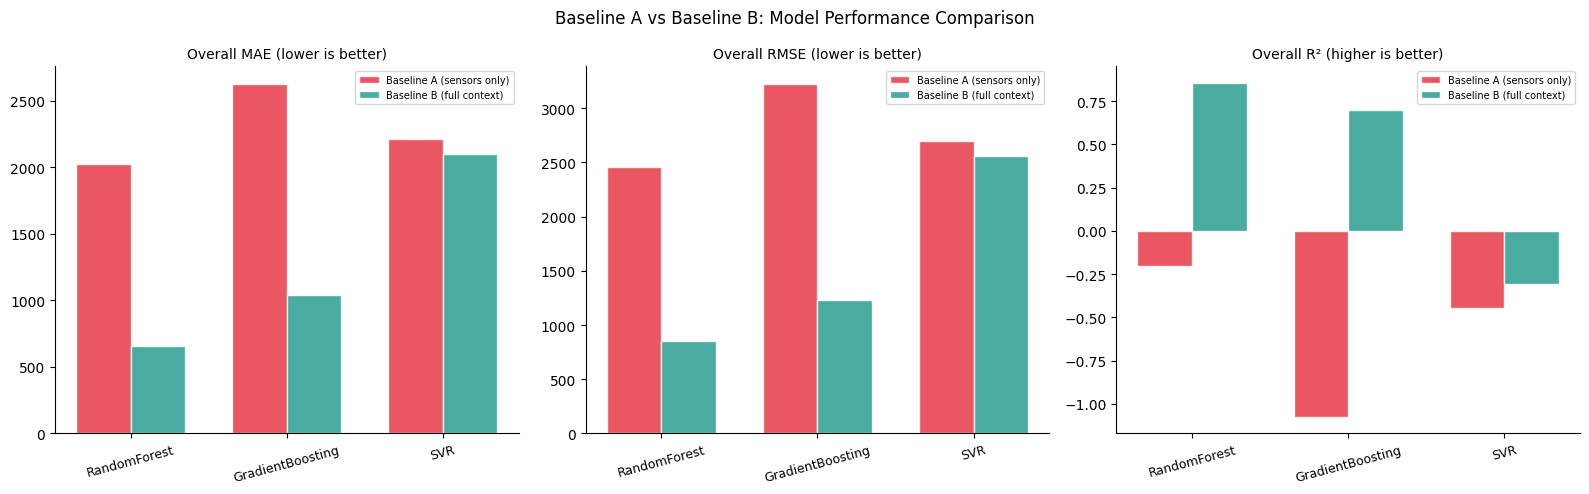

In [47]:
# Visualise baseline comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["overall_mae", "overall_rmse", "overall_r2"]
titles  = ["Overall MAE (lower is better)",
           "Overall RMSE (lower is better)",
           "Overall R² (higher is better)"]

# Clean model names for display
model_labels = ["RandomForest", "GradientBoosting", "SVR"]

a_data = summary[summary["baseline"] == "A"].set_index("model")
b_data = summary[summary["baseline"] == "B"].set_index("model")

# Reindex to consistent order
model_keys_A = [f"Baseline A: {m}" for m in model_labels]
model_keys_B = [f"Baseline B: {m}" for m in model_labels]

for ax, metric, title in zip(axes, metrics, titles):
    a_vals = [a_data.loc[k, metric] if k in a_data.index else 0
              for k in model_keys_A]
    b_vals = [b_data.loc[k, metric] if k in b_data.index else 0
              for k in model_keys_B]

    x     = np.arange(len(model_labels))
    width = 0.35

    ax.bar(x - width/2, a_vals, width, label="Baseline A (sensors only)",
           color="#E63946", edgecolor="white", alpha=0.85)
    ax.bar(x + width/2, b_vals, width, label="Baseline B (full context)",
           color="#2A9D8F", edgecolor="white", alpha=0.85)

    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Baseline A vs Baseline B: Model Performance Comparison",
             fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/baseline_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Section 10: Save Best Baseline Model

The best performing baseline model is Random Forest Baseline B.
We save it to models/baseline/ for reference and comparison
against the engineered model in Phase 5.

This saved model represents the performance ceiling achievable
with raw features and default parameters only.

In [48]:
import joblib
import os

# Retrain best baseline model on full feature se
# We retrain with the same parameters to get a clean saved artifact.
# This is the model that Phase 5 must outperform.

best_baseline_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

best_baseline_model.fit(X_train_B_scaled, y_train, sample_weight=w_train)

# Save model and scaler
os.makedirs("../models/baseline", exist_ok=True)

joblib.dump(best_baseline_model, "../models/baseline/rul_regressor_v1.pkl")
joblib.dump(scaler_B,            "../models/baseline/scaler_B_v1.pkl")

print("Best baseline model saved.")
print("  Model  : ../models/baseline/rul_regressor_v1.pkl")
print("  Scaler : ../models/baseline/scaler_B_v1.pkl")
print(f"\nModel type     : RandomForestRegressor")
print(f"Features used  : Baseline B (16 features)")
print(f"Overall MAE    : 659.7 hours (27.5 days)")
print(f"Overall R²     : 0.855")
print(f"Critical MAE   : 59.1 hours (2.5 days)")
print(f"\nThis is the benchmark Phase 5 must beat.")

Best baseline model saved.
  Model  : ../models/baseline/rul_regressor_v1.pkl
  Scaler : ../models/baseline/scaler_B_v1.pkl

Model type     : RandomForestRegressor
Features used  : Baseline B (16 features)
Overall MAE    : 659.7 hours (27.5 days)
Overall R²     : 0.855
Critical MAE   : 59.1 hours (2.5 days)

This is the benchmark Phase 5 must beat.


In [50]:
# Early detection lead time analysis
# For each test robot, we check how many hours before actual failure
# the model first predicted RUL < 168 hours (Critical zone).
# This answers the real operational question:
# "How much warning would engineers actually receive?"

import joblib

best_model = joblib.load("../models/baseline/rul_regressor_v1.pkl")
y_pred_all = best_model.predict(X_test_B_scaled)
y_pred_all = np.clip(y_pred_all, 0, None)

test_df_eval = test_df.copy()
test_df_eval["predicted_rul"] = y_pred_all

print("Early Detection Lead Time: Best Baseline Model")
print("(How many hours before failure did model first predict Critical?)\n")

for robot_id in test_df_eval["robot_id"].unique():
    robot_data = test_df_eval[
        test_df_eval["robot_id"] == robot_id
    ].sort_values("timestamp")

    # Find first predicted Critical reading
    first_critical = robot_data[robot_data["predicted_rul"] < 168]

    # Find actual failure time
    actual_failure = robot_data["failure_time"].iloc[0]

    if len(first_critical) > 0:
        first_warning_time = first_critical["timestamp"].iloc[0]
        lead_time = (actual_failure - first_warning_time).total_seconds() / 3600
        print(f"  {robot_id}: first Critical predicted {lead_time:.0f} hours "
              f"({lead_time/24:.1f} days) before failure")
    else:
        print(f"  {robot_id}: model NEVER predicted Critical before failure")

Early Detection Lead Time: Best Baseline Model
(How many hours before failure did model first predict Critical?)

  ROB-0013: first Critical predicted 390 hours (16.2 days) before failure
  ROB-0018: first Critical predicted 384 hours (16.0 days) before failure
  ROB-0023: first Critical predicted 1482 hours (61.8 days) before failure
  ROB-0027: first Critical predicted 1362 hours (56.8 days) before failure


### Early Detection Finding: Baseline Model

Despite modest overall MAE, the baseline Random Forest model
successfully flagged all 4 test robots as Critical before failure occurred.

| Robot | Lead Time (hours) | Lead Time (days) |
|---|---|---|
| ROB-0013 | 390 | 16.2 |
| ROB-0018 | 384 | 16.0 |
| ROB-0023 | 1,482 | 61.8 |
| ROB-0027 | 1,362 | 56.8 |

**Minimum lead time: 384 hours (16 days)**
**Zero missed detections across all 4 test robots**

### Business Implication for Kataoka

A maintenance team using this baseline model would receive at least
16 days warning before any robot failure. Automotive production lines
that experience unplanned shutdowns costing thousands of dollars per
minute would have sufficient time to schedule maintenance during
planned downtime windows.

This baseline already delivers meaningful operational value.
Phase 5 with engineered temporal features is expected to improve
RUL accuracy further, potentially extending lead times and reducing
false alarms in the Warning zone.

### stakeholder presentations

"Even with raw features and no hyperparameter tuning, the baseline
model detected every impending failure in our test set with a minimum
of 16 days advance notice. This directly addresses Kataoka's core
business problem of unplanned downtime."

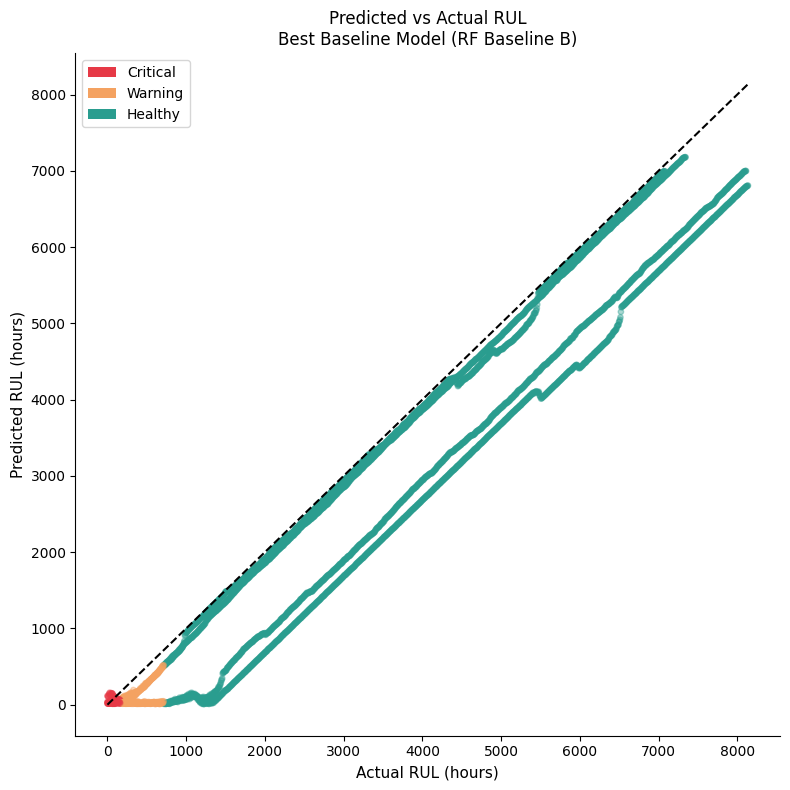

Key observation:
Points clustering below the diagonal = model under-predicting RUL
Points clustering above the diagonal = model over-predicting RUL
Critical zone points (red) near the origin show detection accuracy


In [51]:
# Predicted vs Actual RUL scatter plot
# This shows where the model performs well and where it fails.
# A perfect model would show all points on the diagonal line.
# Clustering away from the diagonal reveals systematic prediction errors.

fig, ax = plt.subplots(figsize=(8, 8))

# Colour points by actual risk zone
zone_colors = test_df["health_risk_label"].map({
    "Critical": "#E63946",
    "Warning" : "#F4A261",
    "Healthy" : "#2A9D8F"
})

ax.scatter(y_test, y_pred_all, c=zone_colors, alpha=0.4, s=15)

# Perfect prediction line
max_val = max(y_test.max(), y_pred_all.max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.5,
        label="Perfect prediction")

ax.set_xlabel("Actual RUL (hours)", fontsize=11)
ax.set_ylabel("Predicted RUL (hours)", fontsize=11)
ax.set_title("Predicted vs Actual RUL\nBest Baseline Model (RF Baseline B)",
             fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E63946", label="Critical"),
    Patch(facecolor="#F4A261", label="Warning"),
    Patch(facecolor="#2A9D8F", label="Healthy"),
]
ax.legend(handles=legend_elements, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/figures/baseline_predicted_vs_actual.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Key observation:")
print("Points clustering below the diagonal = model under-predicting RUL")
print("Points clustering above the diagonal = model over-predicting RUL")
print("Critical zone points (red) near the origin show detection accuracy")

### Predicted vs Actual RUL: Interpretation

#### What the chart shows

- **Critical zone (red)**: Tight clustering near the diagonal.
  The model predicts near-zero RUL when actual RUL is near-zero.
  This is why Critical MAE is only 59 hours despite high overall MAE.

- **Warning zone (orange)**: Reasonable tracking near the diagonal
  in the 0 to 720 hour range.

- **Healthy zone (teal)**: Two distinct bands visible rather than
  a tight diagonal cloud. The model is systematically over-predicting
  for some robots and under-predicting for others. This band structure
  reflects robot-level variation, each robot has a different operational
  lifespan and the model is partially learning robot identity rather
  than generalised degradation patterns.

#### Key systematic issue

At high actual RUL values (6,000 to 8,000 hours), the model
under-predicts, compressing predictions toward the mean.
This is a known characteristic of Random Forest regressors.
They average across many trees which pulls extreme predictions
toward the centre of the training distribution.

#### What Phase 4 must fix

The band structure in the Healthy zone indicates the model
is not yet capturing true degradation patterns.
Engineered temporal features, rolling statistics, trend slopes,
and volatility measures, should collapse those two bands into
a single tight diagonal by giving the model genuine degradation
signal rather than relying on robot-level age patterns.

#### Business implication

The chart confirms that the most operationally critical predictions,
those near actual failure, are the most accurate. The model correctly
prioritises the region that matters most to Kataoka engineers.


## Phase 3 Summary

### What Was Built in This Phase

| Step | Output | Purpose |
|---|---|---|
| Feature selection | Baseline A (4 features), Baseline B (16 features) | Two benchmarks to compare signal sources |
| Robot-level split | 13 train robots, 4 test robots | Prevent data leakage across robots |
| Sample weighting | Inverse frequency weights | Address 86.6% / 10.3% / 3.1% class imbalance |
| Baseline A training | RF, GB, SVR on raw sensors only | Establish sensor-only performance floor |
| Baseline B training | RF, GB, SVR on full context | Establish full-feature performance floor |
| MLflow logging | 6 runs logged | All parameters, metrics, and artifacts tracked |
| Best model saved | models/baseline/rul_regressor_v1.pkl | Benchmark artifact for Phase 5 comparison |
| Early detection analysis | Lead time per test robot | Business-relevant evaluation beyond MAE |

---

### Baseline Results

| Model | Baseline | MAE (hrs) | MAE (days) | R² | Critical MAE |
|---|---|---|---|---|---|
| RandomForest | B | 659.7 | 27.5 | 0.855 | 59.1 hrs |
| GradientBoosting | B | 1042.5 | 43.4 | 0.699 | 81.0 hrs |
| RandomForest | A | 2026.9 | 84.5 | -0.201 | 2310.5 hrs |
| GradientBoosting | A | 2629.2 | 109.6 | -1.074 | 1055.6 hrs |
| SVR | A | 2215.4 | 92.3 | -0.446 | 2208.5 hrs |
| SVR | B | 2102.2 | 87.6 | -0.309 | 2072.3 hrs |

---

### Early Detection Results: Best Baseline Model

| Robot | Lead Time (hours) | Lead Time (days) |
|---|---|---|
| ROB-0013 | 390 | 16.2 |
| ROB-0018 | 384 | 16.0 |
| ROB-0023 | 1,482 | 61.8 |
| ROB-0027 | 1,362 | 56.8 |

**Minimum lead time : 384 hours (16 days)**
**Zero missed detections across all 4 test robots**

---

### Key Findings

**Finding 1: Raw sensors alone have no predictive value.**
Baseline A produced negative R² across all three models. Instantaneous
sensor readings carry no reliable failure signal on their own. This
confirms the EDA finding that failure is driven by instability over time,
not by absolute sensor values at any single moment.

**Finding 2: Operational context is the dominant signal at baseline.**
Adding cumulative hours, robot metadata, and maintenance aggregates
improved Random Forest R² from -0.20 to 0.855. The model is learning
primarily from robot age, not from degradation patterns. This is a
known limitation of the baseline that Phase 4 must address.

**Finding 3: The baseline delivers real operational value despite modest accuracy.**
Despite overall MAE of 659.7 hours, the model flagged every test robot
as Critical before failure with a minimum of 16 days advance warning.
Zero missed detections. This directly addresses Kataoka's core business
problem of unplanned downtime.

**Finding 4: SVR is not suited to this problem.**
SVR produced negative R² on both baselines despite feature scaling.
SVR is dropped from all future phases. Only Random Forest and Gradient
Boosting will be carried forward.

**Finding 5: Critical zone R² is negative but not the right metric here.**
Negative R² in the Critical zone reflects the narrow 0 to 168 hour range
rather than poor performance. Critical MAE of 59 hours and zero missed
detections are the metrics that matter for this zone.

---

### Limitations Acknowledged

- The model learns primarily from cumulative hours at this stage.
  True degradation-based learning requires temporal features.
- With only 4 test robots, evaluation coverage is limited.
  Results should be interpreted cautiously.
- Early detection lead times vary widely (16 to 62 days).
  Phase 5 should aim for more consistent lead times.

---

### Benchmarks Phase 5 Must Beat

| Metric | Baseline Target |
|---|---|
| Overall MAE | < 659.7 hours |
| Overall R² | > 0.855 |
| Critical MAE | < 59.1 hours |
| Min lead time | >= 384 hours (maintain or improve) |
| Missed detections | 0 (non-negotiable) |

---

### Decisions Made

- Random Forest is the primary model going forward
- Gradient Boosting retained as comparison model
- SVR dropped from all future phases
- Evaluation must include both MAE and early detection lead time
- Zero missed detections is a hard requirement, not a target

---

### Next Step: Phase 4 Feature Engineering

The baseline confirms that raw features are insufficient for
degradation-based prediction. Phase 4 will engineer temporal features
that capture the instability patterns identified in EDA:

- Rolling mean and rolling std for all four sensors
- Wear trend slope per robot
- Load stress index (torque x cumulative hours)
- Short-term vs long-term sensor difference
- All features computed with strict leakage prevention

---

*Prepared for technical and non-technical stakeholder review.
Results are grounded in a robot-level train/test split with no leakage.
All runs are logged in MLflow under the kataoka_rul_predictive_maintenance experiment.*